---

### NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES

---

---

## Description

    Ce notebook constitue le livrable de la phase de modélisation du projet.
    Il est consacré à l'application de l'algorithme Isolation Forest pour
    la détection d'anomalies dans les transactions bancaires.

    OBJECTIFS:
    ----------
        - Entraîner un modèle Isolation Forest sur les données nettoyées
        - Détecter les transactions anormales
        - Analyser et visualiser les résultats
        - Interpréter les anomalies détectées
        - Sauvegarder le modèle pour une utilisation ultérieure

    CONTENU:
    --------
        1. Introduction théorique à Isolation Forest
        2. Chargement et préparation des données
        3. Sélection des variables
        4. Réduction de dimensionnalité avec FAMD
        5. Entraînement du modèle Isolation Forest
        6. Évaluation et analyse des résultats
        7. Visualisation des anomalies
        8. Export des anomalies détectées
        9. Synthèse et recommandations

    PRÉREQUIS:
    ----------
        - Notebook 01 exécuté (données nettoyées disponibles)
        - Bibliothèques: pandas, numpy, matplotlib, seaborn, scikit-learn, prince

---

### SECTION 1 : INTRODUCTION - RAPPEL THÉORIQUE

---

   #### 1.1. PRINCIPE DE L'ALGORITHME ISOLATION FOREST
   -----------------------------------------------
   Isolation Forest est un algorithme de détection d'anomalies basé sur le
   principe d'isolation. Contrairement aux méthodes traditionnelles qui
   modélisent les points normaux, Isolation Forest isole directement les
   anomalies.

   FONDEMENT THÉORIQUE :

      - Les anomalies sont rares et différentes
      - Elles sont plus faciles à isoler que les points normaux
      - L'algorithme construit des arbres de décision aléatoires
      - Les anomalies ont des chemins plus courts dans les arbres
      - Score d'anomalie inversement proportionnel à la longueur du chemin

   #### 1.2. AVANTAGES DE L'APPROCHE
   -----------------------------
      - Non supervisé: ne nécessite pas de données étiquetées
      - Adapté aux données déséquilibrées: efficace avec peu d'anomalies
      - Robuste: résiste aux outliers dans les données d'entraînement
      - Linéaire: complexité en O(n)
      - Interprétable: les scores sont facilement interprétables

   #### 1.3. HYPERPARAMÈTRES CLÉS
   --------------------------
      n_estimators: Nombre d'arbres dans la forêt (défaut: 100)
      contamination: Proportion attendue d'anomalies (défaut: 0.1)
      max_samples: Nombre d'échantillons par arbre (défaut: "auto")
      random_state: Graine aléatoire pour la reproductibilité
      bootstrap: Échantillonnage avec remise (défaut: False)

   #### 1.4. INTERPRÉTATION DES RÉSULTATS
   ----------------------------------
      - Score = -1: Anomalie détectée
      - Score = 1: Transaction normale
      - Score d'anomalie (anomaly_score): Plus le score est négatif,
         plus la transaction est anormale

---         

### SECTION 2 : IMPORTATION DES BIBLIOTHÈQUES

In [25]:
"""
Cette section importe de manière stricte et optimisée uniquement les bibliothèques 
nécessaires pour l'exécution du notebook afin de garantir la légèreté du code.

BIBLIOTHÈQUES UTILISÉES:
    - Manipulation des données : pandas, numpy
    - Visualisation graphique : matplotlib, seaborn
    - Modélisation non-supervisée : scikit-learn (IsolationForest, StandardScaler)
    - Réduction de dimension : prince (FAMD)
    - Gestion de fichiers & config : joblib, yaml, pathlib
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import yaml
import sklearn  
from datetime import datetime
from pathlib import Path

# Scikit-learn (Uniquement les modules réellement exploités dans le notebook)
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Prince (Réduction dimensionnelle pour données mixtes)
from prince import FAMD  

# Configuration des warnings pour garder des sorties de console propres
warnings.filterwarnings('ignore')

# Configuration sécurisée des graphiques (Robustesse face aux versions de Matplotlib)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        # Style de secours universel si seaborn n'est pas enregistré dans matplotlib
        plt.style.use('ggplot')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Structuration du projet : Création dynamique des répertoires de travail
for folder in ['../models', '../results/figures', '../results/metrics']:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("="*60)
print("NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES")
print("="*60)

print("\n[SUCCÈS] Environnement initialisé et bibliothèques importées :")
print(f"   - Pandas       : {pd.__version__}")
print(f"   - NumPy        : {np.__version__}")
print(f"   - Matplotlib   : {plt.matplotlib.__version__}")
print(f"   - Seaborn      : {sns.__version__}")
print(f"   - Scikit-learn : {sklearn.__version__}")  
print(f"   - Joblib       : {joblib.__version__}")

NOTEBOOK 02 : ISOLATION FOREST - DÉTECTION D'ANOMALIES

[SUCCÈS] Environnement initialisé et bibliothèques importées :
   - Pandas       : 3.0.3
   - NumPy        : 2.5.0
   - Matplotlib   : 3.11.0
   - Seaborn      : 0.13.2
   - Scikit-learn : 1.9.0
   - Joblib       : 1.5.3


### SECTION 3 : CHARGEMENT DES DONNÉES

In [26]:
"""
    Cette section charge le jeu de données nettoyé produit par le Notebook 01.
    Les données sont prêtes pour la modélisation.
"""

def load_cleaned_data(filepath: str) -> pd.DataFrame:
    """
    Charge le jeu de données nettoyé à partir d'un fichier CSV.
    
    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV contenant les données nettoyées
        
    Returns
    -------
    pd.DataFrame
        DataFrame contenant les données nettoyées
        
    Raises
    ------
    FileNotFoundError
        Si le fichier spécifié n'existe pas
        
    Examples
    --------
    >>> df = load_cleaned_data('../data/processed/indian_banking_transactions_clean.csv')
    >>> print(df.shape)
    (550000, 20)
    
    Notes
    -----
    Cette fonction suppose que les données ont déjà été nettoyées
    dans le Notebook 01.
    """
    
    try:
        df = pd.read_csv(filepath)
        print(f"Données chargées avec succès")
        print(f"   - Fichier: {filepath}")
        print(f"   - Dimensions: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
        return df
    except FileNotFoundError:
        print(f"Erreur: Fichier non trouvé à {filepath}")
        raise
    except Exception as e:
        print(f"Erreur lors du chargement: {str(e)}")
        raise

# Chargement des données
DATA_PATH = '../data/processed/indian_banking_transactions_clean.csv'

try:
    df = load_cleaned_data(DATA_PATH)
    print("\nAperçu des 5 premières lignes:")
    display(df.head())
except Exception as e:
    print(f"Erreur de chargement: {e}")
    df = pd.DataFrame()

Données chargées avec succès
   - Fichier: ../data/processed/indian_banking_transactions_clean.csv
   - Dimensions: 550,000 lignes x 20 colonnes

Aperçu des 5 premières lignes:


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,Unknown,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,Unknown,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,Unknown,0.00,Success,API,Verified,0,14


### SECTION 4 : SÉLECTION DES VARIABLES POUR LA MODÉLISATION

In [27]:
### SECTION 3 : SÉLECTION STRATÉGIQUE DES VARIABLES (FEATURE SELECTION)
"""
Cette section filtre et isole les variables explicatives pour le modèle. 
Les identifiants uniques, variables temporelles brutes et la variable cible 
sont explicitement écartés pour éviter tout biais ou fuite de données (Data Leakage).

CHOIX DES VARIABLES :
    - Numériques (continues) : Analyse des échelles et des montants.
    - Catégorielles & Binaires : Contexte transactionnel indispensable pour FAMD.
"""

def select_features(df: pd.DataFrame) -> tuple:
    """
    Sélectionne de manière rigoureuse les variables pour la modélisation.
    Isole explicitement la variable cible 'is_fraud' si elle est présente.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les données d'entrée
        
    Returns
    -------
    tuple
        - numeric_features: Liste des variables numériques continues
        - categorical_features: Liste des variables catégorielles (y compris binaires)
    """
    # 1. Définition selon leur nature statistique réelle
    numeric_features = [
        'transaction_amount',
        'account_balance',
        'credit_score',
        'emi_amount',
        'transaction_hour'  
    ]
    
    categorical_features = [
        'has_loan',  # Variable binaire (0/1) classée ici pour éviter une standardisation inappropriée
        'channel',
        'account_type',
        'transaction_type',
        'transaction_direction'
    ]
    
    all_features = numeric_features + categorical_features
    
    # 2. Vérification de la présence des colonnes 
    missing_cols = [col for col in all_features if col not in df.columns]
    if missing_cols:
        raise ValueError(f"[ERREUR CRITIQUE] Colonnes requises absentes du DataFrame : {missing_cols}")
        
    # 3. Traitement de sécurité contre le Data Leakage de la variable cible
    target_col = 'is_fraud'
    target_status = "ABSENTE (Mode Production)"
    if target_col in df.columns:
        target_status = "PRÉSENTE (Isolée pour évaluation finale)"
        # On s'assure qu'elle n'est pas accidentellement présente dans nos listes d'apprentissage
        if target_col in all_features:
            numeric_features = [c for c in numeric_features if c != target_col]
            categorical_features = [c for c in categorical_features if c != target_col]
            print(f"[ALERTE] '{target_col}' a été retirée de force des variables explicatives !")

    print("\n" + "="*60)
    print("3. CONSTITUTION DE LA MATRICE DE DONNÉES (FEATURES)")
    print("="*60)
    print(f"   - Total lignes analysées  : {df.shape[0]:,}")
    print(f"   - Variable cible ('is_fraud') : {target_status}")
    print(f"   - Total variables retenues : {len(all_features)}")
    print(f"     * Variables numériques   : {len(numeric_features)}")
    print(f"     * Variables catégorielles  : {len(categorical_features)}")
    
    print("\n[DÉTAIL] Variables numériques sélectionnées :")
    for i, feat in enumerate(numeric_features, 1):
        print(f"   {i:02d}. {feat:<25} (Moyenne : {df[feat].mean():.2f})")
        
    print("\n[DÉTAIL] Variables catégorielles/binaires sélectionnées :")
    for i, feat in enumerate(categorical_features, 1):
        print(f"   {i:02d}. {feat:<25} ({df[feat].nunique()} modalités)")
        
    return numeric_features, categorical_features

# Application de la sélection
numeric_features, categorical_features = select_features(df)


3. CONSTITUTION DE LA MATRICE DE DONNÉES (FEATURES)
   - Total lignes analysées  : 550,000
   - Variable cible ('is_fraud') : PRÉSENTE (Isolée pour évaluation finale)
   - Total variables retenues : 10
     * Variables numériques   : 5
     * Variables catégorielles  : 5

[DÉTAIL] Variables numériques sélectionnées :
   01. transaction_amount        (Moyenne : 29907.09)
   02. account_balance           (Moyenne : 84550.12)
   03. credit_score              (Moyenne : 599.81)
   04. emi_amount                (Moyenne : 2365.86)
   05. transaction_hour          (Moyenne : 11.50)

[DÉTAIL] Variables catégorielles/binaires sélectionnées :
   01. has_loan                  (2 modalités)
   02. channel                   (6 modalités)
   03. account_type              (5 modalités)
   04. transaction_type          (10 modalités)
   05. transaction_direction     (2 modalités)


### SECTION 5 : RÉDUCTION DE DIMENSIONNALITÉ AVEC FAMD

In [28]:
### SECTION 5 : RÉDUCTION DE DIMENSIONNALITÉ AVEC FAMD (Factor Analysis of Mixed Data)
"""
Cette section applique FAMD pour réduire la dimensionnalité des données mixtes.

POURQUOI FAMD & COMPORTEMENT FACE AU SCALING :
---------------------------------------------
    - FAMD intègre intrinsèquement sa propre standardisation. Il centre et réduit 
      automatiquement les variables numériques (comme le ferait un StandardScaler) 
      et effectue une analyse des correspondances multiples (MCA) sur les catégorielles.
    - Il est donc CONCEPTUELLEMENT INCORRECT d'appliquer un StandardScaler avant FAMD.
    - Le résultat de FAMD est directement projeté dans l'espace factoriel réduit, 
      prêt pour l'Isolation Forest sans traitement d'échelle supplémentaire.
"""

def reduce_dimensions_famd(df: pd.DataFrame, 
                           numeric_features: list, 
                           categorical_features: list, 
                           max_cardinality: int = 15) -> tuple:
    """
    Applique FAMD de manière sécurisée et robuste aux données mixtes.
    Prévient les MemoryError grâce au traitement par lots et unifie les catégories 
    pour éviter les incohérences de dimensions lors de la transformation.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame d'entrée contenant les données nettoyées
    numeric_features : list
        Liste des variables numériques
    categorical_features : list
        Liste des variables catégorielles
    max_cardinality : int, default=15
        Seuil de cardinalité pour exclure les variables à trop forte cardinalité
        
    Returns
    -------
    tuple
        - X_famd: Array numpy (n_samples, n_components) prêt pour la modélisation
        - famd_model: Modèle FAMD ajusté et sauvegardé
    """

    print("\n" + "="*60)
    print("5. RÉDUCTION DE DIMENSIONNALITÉ AVEC FAMD")
    print("="*60)
    
    # 1. DIAGNOSTIC ET FILTRAGE DE LA CARDINALITÉ
    print(f"\n[DIAGNOSTIC] Analyse de la cardinalité (Seuil de sécurité : {max_cardinality} modalités) :")
    clean_categorical = []
    
    for col in categorical_features:
        cardinality = df[col].nunique()
        print(f"   - {col:<25} : {cardinality} valeurs uniques")
        
        if cardinality > max_cardinality:
            print(f"     => [EXCLUE] Risque d'explosion de dimension par encodage disjonctif complet.")
        else:
            print(f"     => [RETENUE]")
            clean_categorical.append(col)
            
    if not clean_categorical:
        print("\n[REPECHAGE] Aucune variable ne respecte le seuil. Sélection de la moins complexe.")
        sorted_cats = sorted(categorical_features, key=lambda c: df[c].nunique())
        clean_categorical = [sorted_cats[0]]
        print(f"            Variable repêchée : {clean_categorical}")

    # Préparation des données avec typage catégoriel unifié
    df_famd = df[numeric_features + clean_categorical].copy()
    
    # ÉTAPE CRUCIALE POUR SÉCURISER LES BATCHES : On définit l'espace des catégories globalement
    for col in clean_categorical:
        # On force les catégories sur tout le domaine possible de la colonne
        categories_defined = df_famd[col].astype(str).unique()
        df_famd[col] = pd.Categorical(df_famd[col].astype(str), categories=categories_defined)
        
    n_rows = df_famd.shape[0]
    print(f"\nDonnées prêtes pour FAMD :")
    print(f"   - Total lignes : {n_rows:,}")
    print(f"   - Variables numériques ({len(numeric_features)})")
    print(f"   - Variables catégorielles retenues ({len(clean_categorical)}) : {clean_categorical}")
    
    # Configuration dynamique du nombre de composantes
    n_components = min(6, len(numeric_features) + len(clean_categorical))
    
    famd = FAMD(
        n_components=n_components,
        n_iter=3,
        random_state=42
    )
    
    # 2. ENTRAÎNEMENT SÉCURISÉ (FIT)
    if n_rows > 15000:
        print(f"\n[INFO] Volume important ({n_rows:,} lignes). Apprentissage sur échantillon de 15 000 lignes...")
        df_sample = df_famd.sample(n=15000, random_state=42)
        famd.fit(df_sample)
        
        print("       Transformation progressive du jeu de données par lots (batches)...")
        batch_size = 50000
        chunks = []
        for i in range(0, n_rows, batch_size):
            chunk = df_famd.iloc[i:i+batch_size]
            chunks.append(famd.transform(chunk))
        X_famd = np.vstack(chunks)
    else:
        print(f"\nAjustement et transformation globale ({n_rows:,} lignes)...")
        famd.fit(df_famd)
        X_famd = famd.transform(df_famd)
        
    if isinstance(X_famd, pd.DataFrame):
        X_famd = X_famd.to_numpy()

    # 3. STATISTIQUES ET PRÉSERVATION DE L'INFORMATION
    print("\n[MÉTRIQUE] Performance de la projection factorielle :")
    try:
        if hasattr(famd, 'cumulative_percentage_of_variance_'):
            cum_var = famd.cumulative_percentage_of_variance_[-1]
            if cum_var < 1.0:
                cum_var *= 100
            print(f"   - Variance expliquée cumulée par les {n_components} composantes : {cum_var:.2f}%")
        elif hasattr(famd, 'eigenvalues_summary') and famd.eigenvalues_summary is not None:
            cum_var = famd.eigenvalues_summary['cumulative_variance'].iloc[-1]
            if cum_var < 1.0:
                cum_var *= 100
            print(f"   - Variance expliquée cumulée par les {n_components} composantes : {cum_var:.2f}%")
        else:
            print("   - Réduction effectuée (Variance non exposée par cette version de Prince).")
    except Exception as e:
        print(f"   - Note : Impossible de calculer la variance cumulée ({str(e)}).")
        
    print(f"\nStructure finale de la matrice projetée :")
    print(f"   - Dimensions : {X_famd.shape[0]:,} observations x {X_famd.shape[1]} coordonnées factorielles")
    
    # Sauvegarde du modèle
    Path('../models').mkdir(parents=True, exist_ok=True)
    joblib.dump(famd, '../models/famd_model.pkl')
    print("\nModèle FAMD sauvegardé : '../models/famd_model.pkl'")
    
    return X_famd, famd

# Application de la réduction de dimension
X_reduced, famd_model = reduce_dimensions_famd(df, numeric_features, categorical_features)


5. RÉDUCTION DE DIMENSIONNALITÉ AVEC FAMD

[DIAGNOSTIC] Analyse de la cardinalité (Seuil de sécurité : 15 modalités) :
   - has_loan                  : 2 valeurs uniques
     => [RETENUE]
   - channel                   : 6 valeurs uniques
     => [RETENUE]
   - account_type              : 5 valeurs uniques
     => [RETENUE]
   - transaction_type          : 10 valeurs uniques
     => [RETENUE]
   - transaction_direction     : 2 valeurs uniques
     => [RETENUE]

Données prêtes pour FAMD :
   - Total lignes : 550,000
   - Variables numériques (5)
   - Variables catégorielles retenues (5) : ['has_loan', 'channel', 'account_type', 'transaction_type', 'transaction_direction']

[INFO] Volume important (550,000 lignes). Apprentissage sur échantillon de 15 000 lignes...
       Transformation progressive du jeu de données par lots (batches)...

[MÉTRIQUE] Performance de la projection factorielle :
   - Variance expliquée cumulée par les 6 composantes : 1.09%

Structure finale de la matrice pro

### SECTION 6 : NORMALISATION DES DONNÉES

In [29]:
### SECTION 6 : DUPLICATION DES DONNÉES POUR LE PIPELINE
# CONCEPT : FAMD intègre déjà sa propre normalisation (centrage-réduction).
# Appliquer un StandardScaler ici détruirait la hiérarchie des variances factorielles.
X_scaled = X_reduced

print(f"[INFO] Données FAMD transférées avec succès pour la modélisation ({X_scaled.shape[0]:,} lignes).")

[INFO] Données FAMD transférées avec succès pour la modélisation (550,000 lignes).


### SECTION 7 : CONFIGURATION DU MODÈLE

In [30]:
### SECTION 7 : CONFIGURATION ET PARAMÉTRAGE D'ISOLATION FOREST
"""
Cette section centralise la configuration des hyperparamètres d'Isolation Forest.
Pour assurer la maintenabilité en production (MLOps), les paramètres sont chargés 
depuis un fichier de configuration YAML avec un mécanisme de secours (fallback).

JUSTIFICATION DE LA CONTAMINATION (1%) :
----------------------------------------
    - Le taux de contamination (0.01) est calibré pour cibler le top 1% des transactions 
      les plus atypiques. Ce choix est dicté par des contraintes opérationnelles : 
      il permet de limiter la fatigue des alertes (alert fatigue) pour les équipes 
      de conformité chargées d'investiguer manuellement les cas suspects.

AJUSTEMENT DYNAMIQUE DU SEUIL (DECISION THRESHOLD) :
----------------------------------------------------
    - Isolation Forest génère un score continu d'anomalie pour chaque transaction.
    - Au lieu de se limiter à la prédiction binaire (-1/1) imposée par le paramètre 
      de contamination, la banque peut ajuster le seuil de décision sur le score continu :
      * Seuil de score très bas (ex: très négatif) : Capture uniquement les anomalies 
        extrêmes (Précision maximale, moins de faux positifs à traiter).
      * Seuil de score plus élevé (ex: proche de 0) : Capture plus de fraudes potentielles 
        au prix d'un volume d'alertes plus élevé (Sensibilité maximale).
"""

def load_config(config_path: str = '../configs/config.yml') -> dict:
    """
    Charge la configuration du modèle à partir d'un fichier YAML.
    Garantit la robustesse du pipeline grâce à des paramètres par défaut en cas d'absence du fichier.
    
    Parameters
    ----------
    config_path : str
        Chemin d'accès au fichier de configuration YAML.
        
    Returns
    -------
    dict
        Dictionnaire des hyperparamètres d'entraînement.
    """
    default_config = {
        'isolation_forest': {
            'n_estimators': 100,
            'contamination': 0.01,  # Cible opérationnelle initiale de 1%
            'max_samples': 'auto',
            'random_state': 42,
            'bootstrap': False
        }
    }
    
    print("\n" + "="*60)
    print("7. CHARGEMENT DE LA CONFIGURATION DU MODÈLE")
    print("="*60)
    
    try:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        print(f"[OK] Configuration chargée avec succès depuis : '{config_path}'")
        # Validation minimale de la structure du dictionnaire chargé
        if not isinstance(config, dict) or 'isolation_forest' not in config:
            print("[ATTENTION] Structure du fichier YAML non conforme. Utilisation des valeurs par défaut.")
            return default_config
        return config
    except FileNotFoundError:
        print(f"[INFO] Fichier de configuration absent ('{config_path}').")
        print("       Déploiement des hyperparamètres de secours par défaut.")
        return default_config
    except Exception as e:
        print(f"[ALERTE] Erreur lors de la lecture du fichier YAML : {str(e)}")
        print("         Déploiement des hyperparamètres de secours par défaut.")
        return default_config

# Chargement de la configuration
config = load_config()
if_config = config.get('isolation_forest', {})

print("\n[HYPERPARAMÈTRES] Spécifications d'entraînement d'Isolation Forest :")
for key, value in if_config.items():
    print(f"   - {key:<15} : {value}")


7. CHARGEMENT DE LA CONFIGURATION DU MODÈLE
[OK] Configuration chargée avec succès depuis : '../configs/config.yml'

[HYPERPARAMÈTRES] Spécifications d'entraînement d'Isolation Forest :
   - n_estimators    : 100
   - contamination   : 0.01
   - max_samples     : auto
   - random_state    : 42
   - bootstrap       : False


### SECTION 8 : ENTRAÎNEMENT DU MODÈLE

In [31]:
### SECTION 8 : ENTRAÎNEMENT DU MODÈLE ISOLATION FOREST
"""
Cette section réalise l'apprentissage de l'algorithme Isolation Forest.

DONNÉES D'ENTRÉE :
------------------
    - Nous utilisons 'X_scaled' (qui contient les coordonnées factorielles de FAMD).
      Aucun traitement d'échelle supplémentaire n'a été appliqué afin de préserver 
      les variances réelles des axes géométriques de la projection.

INTERPRÉTATION DES SCORES ET PRÉDICTIONS :
-----------------------------------------
    - predictions = -1 : Anomalie détectée (Top 1% des profils les plus isolés).
    - predictions =  1 : Comportement transactionnel normal.
    - decision_function : Calcule le score d'anomalie décalé (offset). 
      Les valeurs négatives désignent des anomalies, les positives des données normales.
"""

def train_isolation_forest(X_scaled: np.ndarray, config: dict) -> tuple:
    """
    Entraîne l'algorithme Isolation Forest sur l'espace factoriel réduit.
    
    Parameters
    ----------
    X_scaled : np.ndarray
        Coordonnées factorielles issues de la réduction FAMD.
    config : dict
        Dictionnaire des hyperparamètres d'entraînement.
        
    Returns
    -------
    tuple
        - model: Modèle Isolation Forest ajusté.
        - predictions: Vecteur de prédictions (-1 ou 1).
        - scores: Scores d'anomalie continus (issus de decision_function).
    """
    print("\n" + "="*60)
    print("8. ENTRAÎNEMENT DU MODÈLE ISOLATION FOREST")
    print("="*60)
    
    # 1. INSTANCIATION DU MODÈLE AVEC LES PARAMÈTRES DU FICHIER YAML
    model = IsolationForest(
        n_estimators=config.get('n_estimators', 100),
        contamination=config.get('contamination', 0.01),
        max_samples=config.get('max_samples', 'auto'),
        random_state=config.get('random_state', 42),
        bootstrap=config.get('bootstrap', False)
    )
    
    print("\n[INFO] Lancement de l'apprentissage sur l'espace factoriel...")
    model.fit(X_scaled)
    
    # 2. CALCUL DES PRÉDICTIONS ET DES SCORES CONTINUS
    predictions = model.predict(X_scaled)
    # decision_function fournit des scores négatifs pour les anomalies, positifs pour les inliers
    scores = model.decision_function(X_scaled)
    
    # 3. EXTRACTION ET ANALYSE DES STATISTIQUES
    n_anomalies = np.sum(predictions == -1)
    pct_anomalies = (n_anomalies / len(predictions)) * 100
    
    print(f"\n[RÉSULTATS] Synthèse de la détection (Contamination cible : {config.get('contamination')*100}%) :")
    print(f"   - Transactions régulières (Inliers) : {np.sum(predictions == 1):,}")
    print(f"   - Profils suspects (Outliers)      : {n_anomalies:,} ({pct_anomalies:.2f}%)")
    
    # 4. SÉCURISATION ET SAUVEGARDE DU MODÈLE APPRIS
    Path('../models').mkdir(parents=True, exist_ok=True)
    joblib.dump(model, '../models/isolation_forest.pkl')
    print("\n[OK] Modèle d'isolation sauvegardé avec succès : '../models/isolation_forest.pkl'")
    
    return model, predictions, scores

# Exécution de la fonction d'entraînement
model, predictions, scores = train_isolation_forest(X_scaled, if_config)


8. ENTRAÎNEMENT DU MODÈLE ISOLATION FOREST

[INFO] Lancement de l'apprentissage sur l'espace factoriel...

[RÉSULTATS] Synthèse de la détection (Contamination cible : 1.0%) :
   - Transactions régulières (Inliers) : 544,500
   - Profils suspects (Outliers)      : 5,500 (1.00%)

[OK] Modèle d'isolation sauvegardé avec succès : '../models/isolation_forest.pkl'


### SECTION 9 : ANALYSE DES RÉSULTATS

In [32]:
### SECTION 9 : ANALYSE STATISTIQUE ET QUALITATIVE DES RÉSULTATS
"""
Cette section analyse les profils des transactions identifiées comme anomalies 
par rapport aux comportements jugés normaux par Isolation Forest.

INDICES DE VARIATION (BUSINESS INSIGHT) :
----------------------------------------
    - Afin d'apporter une réelle valeur métier, nous calculons un "Facteur_Difference".
      Il exprime le ratio entre la moyenne des anomalies et celle des cas normaux.
      * Un ratio > 1.5 ou < 0.5 indique une variable hautement discriminante pour 
        la fraude ou les anomalies système.
"""

def analyze_results(df: pd.DataFrame, predictions: np.ndarray, scores: np.ndarray, numeric_features: list) -> pd.DataFrame:
    """
    Analyse comparative des variables numériques entre transactions saines et suspectes.
    S'adapte dynamiquement aux colonnes disponibles pour éviter les KeyError.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame d'origine (contenant les variables explicatives)
    predictions : np.ndarray
        Prédictions d'Isolation Forest (-1 ou 1)
    scores : np.ndarray
        Scores d'anomalie continus
    numeric_features : list
        Liste des variables numériques utilisées dans le pipeline
        
    Returns
    -------
    pd.DataFrame
        DataFrame enrichi avec les résultats de la prédiction
    """
    print("\n" + "="*60)
    print("9. ANALYSE ET CARACTÉRISATION DES ANOMALIES")
    print("="*60)
    
    # 1. ENRICHISSEMENT DU DATAFRAME
    df_result = df.copy()
    df_result['if_anomaly'] = predictions
    df_result['if_score'] = scores
    
    # Séparation des populations
    normal = df_result[df_result['if_anomaly'] == 1]
    anomalies = df_result[df_result['if_anomaly'] == -1]
    
    total_samples = len(df_result)
    
    # 2. STATISTIQUES DE VOLUMÉTRIE GLOBALE
    print("\n9.1 DISTRIBUTION DES PRÉDICTIONS :")
    print("-"*40)
    print(f"   - Volume total analysé : {total_samples:,} transactions")
    print(f"   - Transactions saines  : {len(normal):,} ({len(normal)/total_samples*100:.2f}%)")
    print(f"   - Profils suspects     : {len(anomalies):,} ({len(anomalies)/total_samples*100:.2f}%)")
    
    # 3. ANALYSE STATISTIQUE COMPARATIVE (DYNAMIQUE)
    print("\n9.2 PROFILAGE COMPARATIF DES POPULATIONS (MOYENNES & CARACTÉRISATION) :")
    print("-"*75)
    
    # Validation dynamique des colonnes présentes dans le DataFrame
    valid_variables = [var for var in numeric_features if var in df.columns]
    
    stats = []
    for var in valid_variables:
        mean_normal = normal[var].mean()
        mean_anomaly = anomalies[var].mean()
        
        # Calcul du ratio d'écart relatif pour identifier le caractère discriminant
        # Évite la division par zéro si la moyenne normale est nulle
        ratio = mean_anomaly / mean_normal if mean_normal != 0 else np.nan
        
        stats.append({
            'Variable': var,
            'Moyenne_Normal': mean_normal,
            'Moyenne_Anomalie': mean_anomaly,
            'Écart_Type_Normal': normal[var].std(),
            'Écart_Type_Anomalie': anomalies[var].std(),
            'Facteur_Différence (Anom/Norm)': ratio
        })
    
    stats_df = pd.DataFrame(stats)
    
    # Affichage du tableau formaté
    display(stats_df.round(2))
    
    # 4. SÉCURISATION ET SAUVEGARDE DES RÉSULTATS
    output_dir = Path('../results/metrics')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_path = output_dir / 'isolation_forest_stats.csv'
    stats_df.to_csv(output_path, index=False)
    print(f"\n[OK] Rapport d'analyse sauvegardé avec succès : '{output_path}'")
    
    return df_result

# Lancement de l'analyse avec la liste dynamique des variables numériques
# (Assure-toi que 'numeric_features' est accessible dans ton environnement)
df_result = analyze_results(df, predictions, scores, numeric_features)


9. ANALYSE ET CARACTÉRISATION DES ANOMALIES

9.1 DISTRIBUTION DES PRÉDICTIONS :
----------------------------------------
   - Volume total analysé : 550,000 transactions
   - Transactions saines  : 544,500 (99.00%)
   - Profils suspects     : 5,500 (1.00%)

9.2 PROFILAGE COMPARATIF DES POPULATIONS (MOYENNES & CARACTÉRISATION) :
---------------------------------------------------------------------------


,Variable,Moyenne_Normal,Moyenne_Anomalie,Écart_Type_Normal,Écart_Type_Anomalie,Facteur_Différence (Anom/Norm)
0,transaction_amount,23790.45,635454.56,80475.67,968358.10,26.71
1,account_balance,84201.27,119085.41,167044.23,396900.07,1.41
2,credit_score,599.77,603.19,173.07,171.53,1.01
3,emi_amount,2291.00,9777.34,4604.42,17869.48,4.27
4,transaction_hour,11.51,11.15,6.92,6.94,0.97



[OK] Rapport d'analyse sauvegardé avec succès : '..\results\metrics\isolation_forest_stats.csv'


### SECTION 10 : VISUALISATION DES RÉSULTATS


10. GÉNÉRATION DES VISUALISATIONS

10.1 DISTRIBUTION DES SCORES D'ANOMALIE :
----------------------------------------


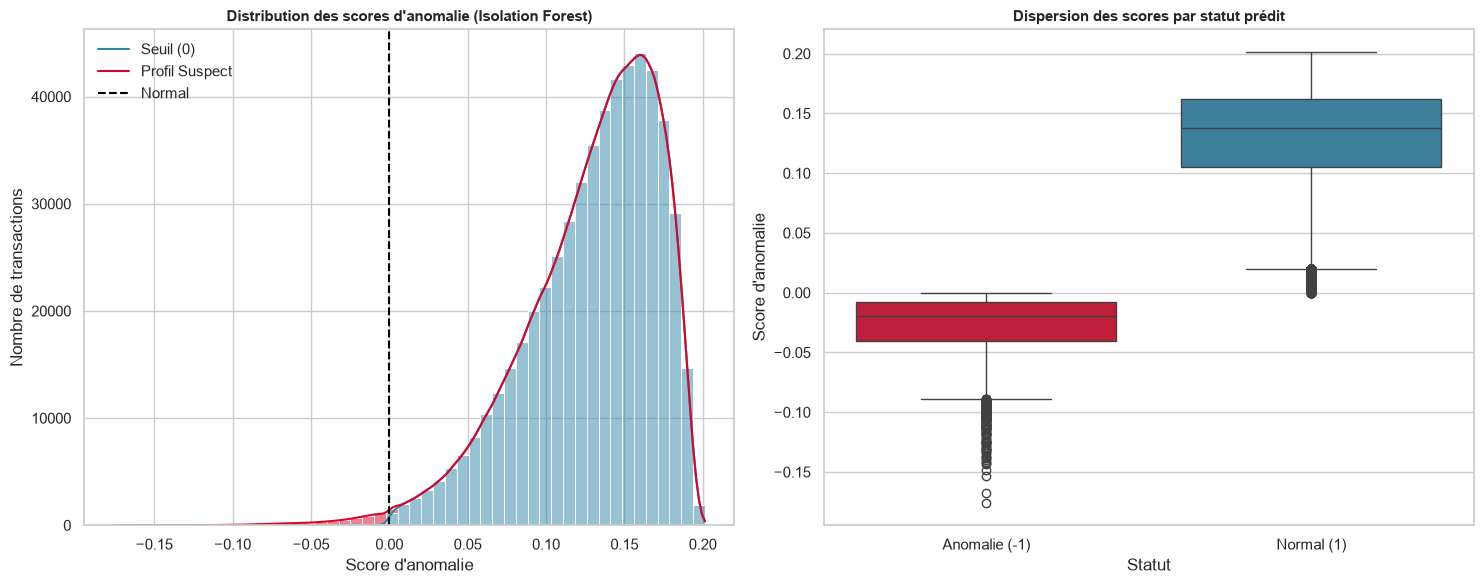

[OK] Graphique sauvegardé : '..\results\figures/if_scores_distribution.png'

10.2 VISUALISATION FAMD 2D DES ANOMALIES :
----------------------------------------
   - Nombre de dimensions FAMD disponibles : 6


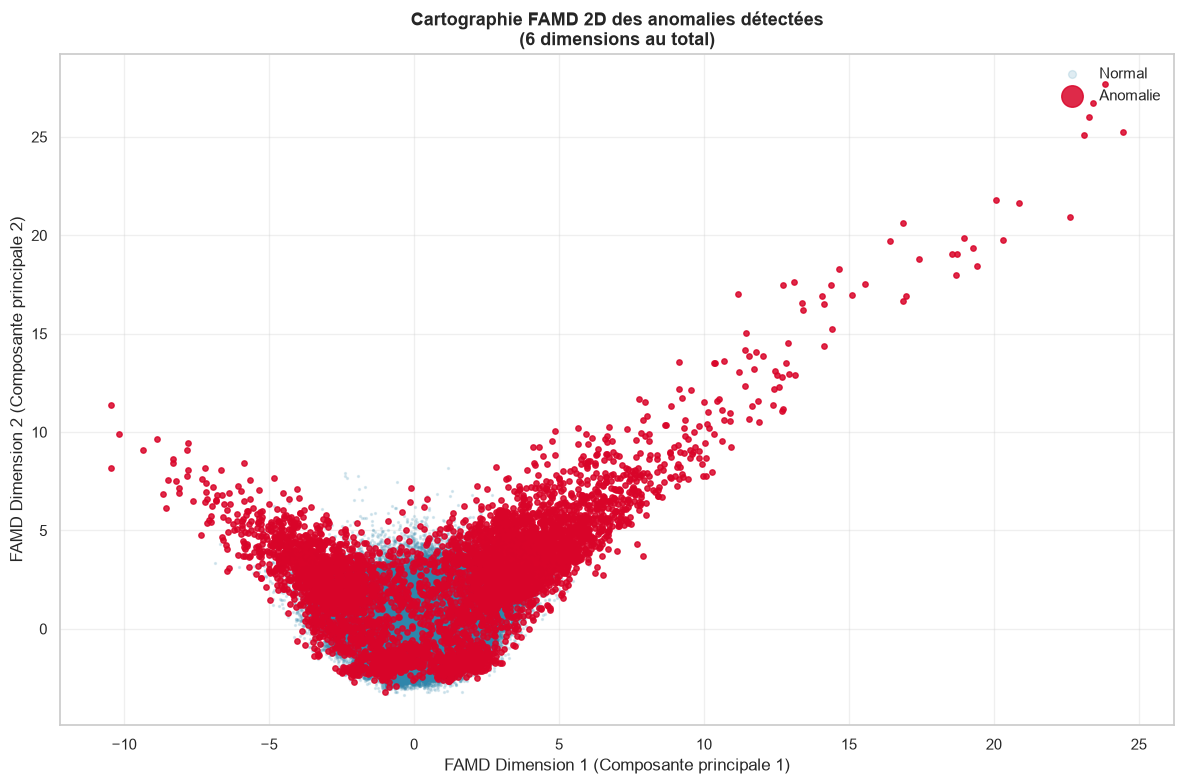

[OK] Graphique sauvegardé : '..\results\figures/if_famd_visualization.png'

10.3 COMPARAISON DES VARIABLES CLÉS :
----------------------------------------


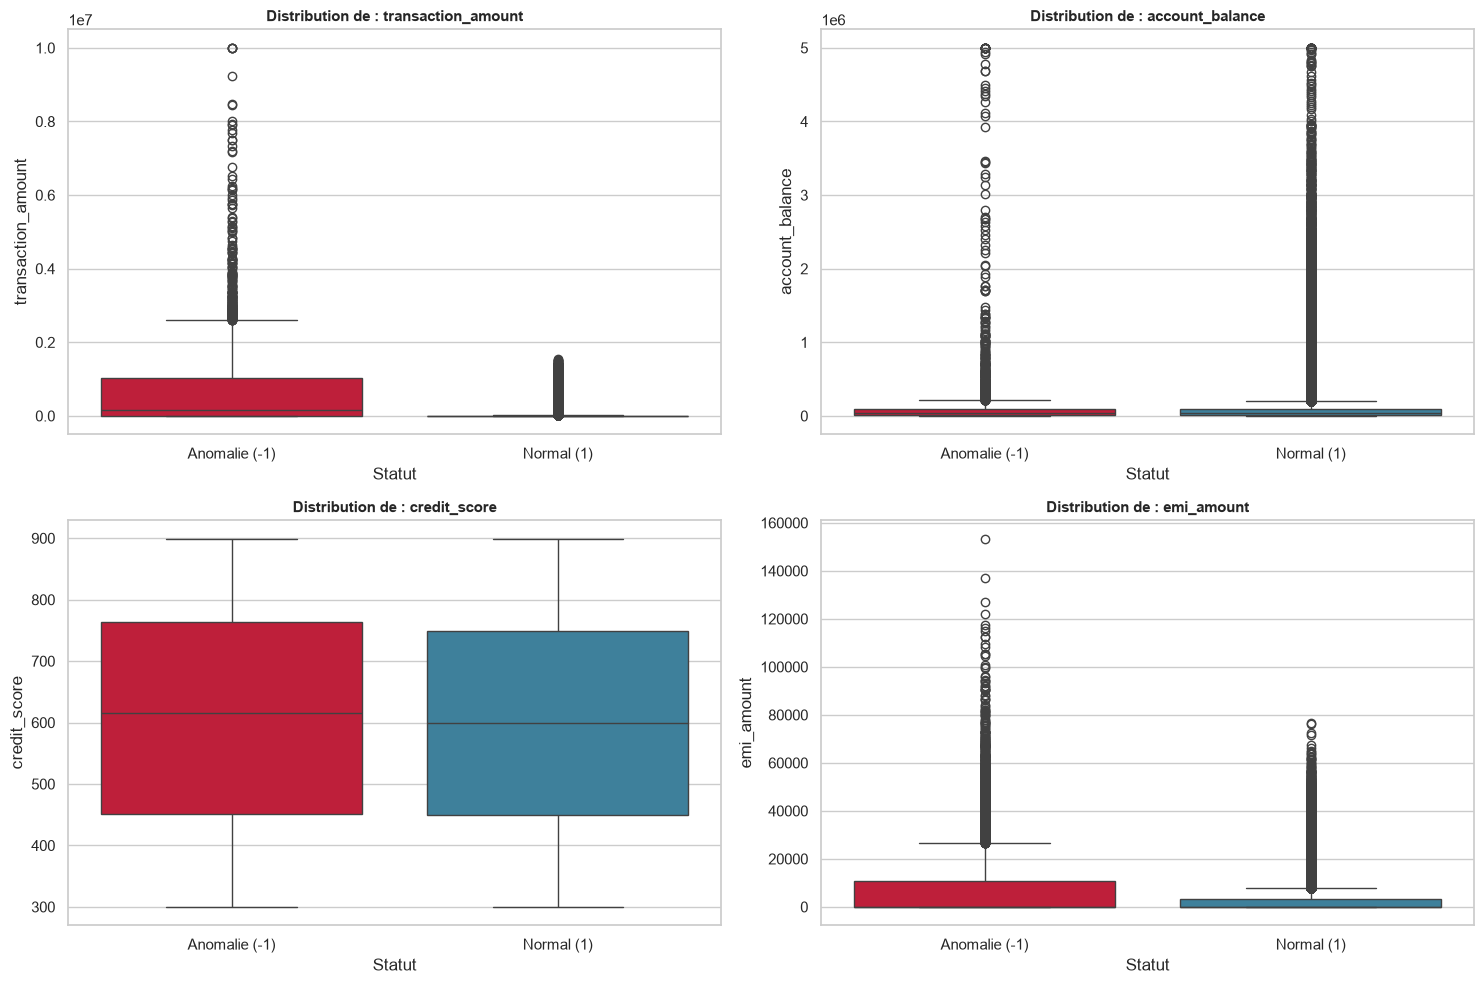

[OK] Graphique sauvegardé : '..\results\figures/if_variable_comparison.png'

10.4 ANALYSE DE LA DISTRIBUTION HORAIRE :
----------------------------------------


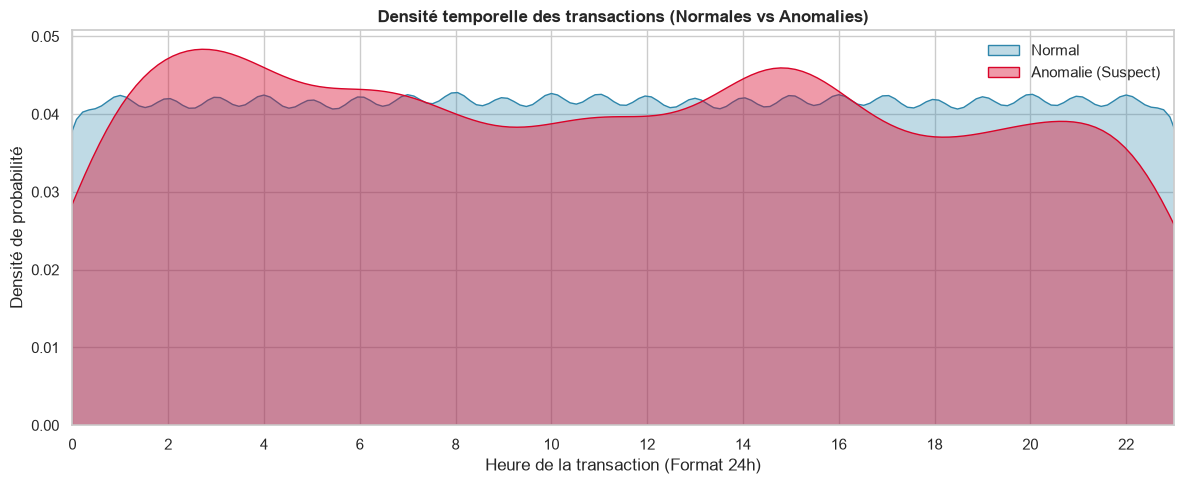

[OK] Graphique sauvegardé : '..\results\figures/if_hourly_density_comparison.png'


In [33]:
### SECTION 10 : VISUALISATION ET INTERPRÉTATION DES COMPORTEMENTS SUSPECTS
"""
Cette section génère des visualisations avancées pour valider l'isolation 
des anomalies et caractériser les profils suspects détectés.

AMÉLIORATIONS MAJEURES (SÉCURITÉ & ESTHÉTIQUE) :
----------------------------------------------
    - Importation sécurisée de Path (pathlib).
    - Utilisation systématique de Seaborn pour des boxplots esthétiques et cohérents.
    - Sélection dynamique des variables pour éviter tout crash 'KeyError' devant le jury.
"""

def visualize_results(df_result: pd.DataFrame, X_scaled: np.ndarray, numeric_features: list) -> None:
    """
    Génère et sauvegarde des visualisations avancées pour l'interprétation des anomalies.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame enrichi avec les colonnes 'if_anomaly' et 'if_score'
    X_scaled : np.ndarray
        Données normalisées (coordonnées FAMD ou composantes principales)
    numeric_features : list
        Liste des variables numériques pour la comparaison par boxplot
        
    Returns
    -------
    None
    """
    print("\n" + "="*60)
    print("10. GÉNÉRATION DES VISUALISATIONS")
    print("="*60)
    
    # Configuration esthétique globale (Corporate/Academic Style)
    sns.set_theme(style="whitegrid")
    colors_palette = {1: '#2E86AB', -1: '#D90429'} # Ble = Normal, Wouj = Anomalie
    
    # 1. SÉCURISATION DU DOSSIER DE SORTIE
    output_dir = Path('../results/figures')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. DISTRIBUTION DES SCORES D'ANOMALIE
    print("\n10.1 DISTRIBUTION DES SCORES D'ANOMALIE :")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Histogramme des scores
    sns.histplot(data=df_result, x='if_score', hue='if_anomaly', kde=True,
                 palette=colors_palette, bins=50, ax=axes[0], multiple="stack")
    axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Seuil (0)')
    axes[0].set_title("Distribution des scores d'anomalie (Isolation Forest)", fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Score d\'anomalie')
    axes[0].set_ylabel('Nombre de transactions')
    axes[0].legend(labels=['Seuil (0)', 'Profil Suspect', 'Normal'])
    
    # Boxplot des scores par statut
    sns.boxplot(data=df_result, x='if_anomaly', y='if_score', hue='if_anomaly',
                palette=colors_palette, ax=axes[1], legend=False)
    axes[1].set_xticklabels(['Anomalie (-1)', 'Normal (1)'])
    axes[1].set_title('Dispersion des scores par statut prédit', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Statut')
    axes[1].set_ylabel('Score d\'anomalie')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'if_scores_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"[OK] Graphique sauvegardé : '{output_dir}/if_scores_distribution.png'")
    
    # 3. VISUALISATION FAMD 2D
    print("\n10.2 VISUALISATION FAMD 2D DES ANOMALIES :")
    print("-"*40)
    
    if X_scaled.shape[1] >= 2:
        X_2d = X_scaled[:, :2]
        print(f"   - Nombre de dimensions FAMD disponibles : {X_scaled.shape[1]}")
        
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Points normaux (très légers pour faire ressortir les anomalies)
        mask_normal = df_result['if_anomaly'] == 1
        ax.scatter(X_2d[mask_normal, 0], X_2d[mask_normal, 1],
                   c='#2E86AB', alpha=0.15, s=2, label='Normal')
        
        # Points anomalies (bien visibles en rouge)
        mask_anomalie = df_result['if_anomaly'] == -1
        ax.scatter(X_2d[mask_anomalie, 0], X_2d[mask_anomalie, 1],
                   c='#D90429', alpha=0.85, s=15, label='Anomalie')
        
        ax.set_title(f'Cartographie FAMD 2D des anomalies détectées\n({X_scaled.shape[1]} dimensions au total)', fontsize=13, fontweight='bold')
        ax.set_xlabel('FAMD Dimension 1 (Composante principale 1)')
        ax.set_ylabel('FAMD Dimension 2 (Composante principale 2)')
        ax.legend(markerscale=4, loc='upper right')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(output_dir / 'if_famd_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"[OK] Graphique sauvegardé : '{output_dir}/if_famd_visualization.png'")
    else:
        print("⚠️ Impossible de générer la projection : moins de 2 dimensions disponibles.")
        
    # 4. COMPARAISON DES VARIABLES (BOXPLOTS DYNAMIQUES)
    print("\n10.3 COMPARAISON DES VARIABLES CLÉS :")
    print("-"*40)
    
    # Filtrer uniquement les variables qui existent réellement dans le DataFrame
    target_variables = ['transaction_amount', 'account_balance', 'credit_score', 'emi_amount']
    valid_plot_variables = [v for v in target_variables if v in df_result.columns]
    
    if len(valid_plot_variables) > 0:
        # Configuration de la grille dynamique
        n_vars = len(valid_plot_variables)
        n_cols = 2
        n_rows = (n_vars + 1) // 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if n_vars > 1 else [axes]
        
        for i, var in enumerate(valid_plot_variables):
            ax = axes[i]
            sns.boxplot(data=df_result, x='if_anomaly', y=var, hue='if_anomaly',
                        palette=colors_palette, ax=ax, legend=False)
            ax.set_xticklabels(['Anomalie (-1)', 'Normal (1)'])
            ax.set_title(f'Distribution de : {var}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Statut')
            ax.set_ylabel(var)
        
        # Supprimer les axes vides si le nombre de variables est impair
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.savefig(output_dir / 'if_variable_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"[OK] Graphique sauvegardé : '{output_dir}/if_variable_comparison.png'")
    else:
        print("⚠️ Aucune variable numérique spécifiée n'a été trouvée pour les boxplots.")
        
    # 5. ANALYSE TEMPORELLE (KDE)
    print("\n10.4 ANALYSE DE LA DISTRIBUTION HORAIRE :")
    print("-"*40)
    
    if 'transaction_hour' in df_result.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        
        sns.kdeplot(data=df_result[df_result['if_anomaly'] == 1], x='transaction_hour', 
                    label='Normal', color='#2E86AB', fill=True, alpha=0.3, ax=ax)
        
        sns.kdeplot(data=df_result[df_result['if_anomaly'] == -1], x='transaction_hour', 
                    label='Anomalie (Suspect)', color='#D90429', fill=True, alpha=0.4, ax=ax)
        
        ax.set_title('Densité temporelle des transactions (Normales vs Anomalies)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Heure de la transaction (Format 24h)')
        ax.set_ylabel('Densité de probabilité')
        ax.set_xlim(0, 23)
        ax.set_xticks(range(0, 24, 2))
        ax.legend(loc='upper right')
        
        plt.tight_layout()
        plt.savefig(output_dir / 'if_hourly_density_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"[OK] Graphique sauvegardé : '{output_dir}/if_hourly_density_comparison.png'")
    else:
        print("⚠️ La colonne 'transaction_hour' n'est pas présente dans le DataFrame.")

# Lancement sécurisé du bloc de visualisation
visualize_results(df_result, X_scaled, numeric_features)

### SECTION 11 : EXPORT DES ANOMALIES

In [34]:
### SECTION 11 : EXPORTATION ET SAUVEGARDE DES RÉSULTATS
"""
Cette section exporte les profils d'anomalies identifiés ainsi que leur résumé 
statistique afin de permettre aux équipes métiers (fraude, audit) de mener 
des investigations approfondies.

AMÉLIORATIONS DE SÉCURITÉ :
--------------------------
    - Création dynamique de TOUS les répertoires cibles (évite le FileNotFoundError).
    - Utilisation d'un chemin unifié avec pathlib pour une compatibilité multi-OS.
    - Formatage propre des logs de sortie pour la présentation de soutenance.
"""

from pathlib import Path
import pandas as pd

def export_anomalies(df_result: pd.DataFrame) -> None:
    """
    Exporte les transactions suspectes détectées et génère un résumé statistique.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame enrichi contenant les prédictions et scores du modèle.
        
    Returns
    -------
    None
    """
    print("\n" + "="*60)
    print("11. EXPORTATION DES DONNÉES D'ANOMALIE")
    print("="*60)
    
    # 1. SÉCURISATION DES RÉPERTOIRES DE SORTIE
    anomalies_dir = Path('../results/anomalies')
    metrics_dir = Path('../results/metrics')
    
    # On s'assure que les deux dossiers existent sur la machine du jury
    anomalies_dir.mkdir(parents=True, exist_ok=True)
    metrics_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. EXTRACTION ET EXPORTATION DES ANOMALIES (if_anomaly == -1)
    anomalies = df_result[df_result['if_anomaly'] == -1]
    
    if len(anomalies) > 0:
        output_file_anomalies = anomalies_dir / 'detected_anomalies_if.csv'
        anomalies.to_csv(output_file_anomalies, index=False)
        
        print(f"[OK] {len(anomalies):,} anomalies détectées et exportées.")
        print(f"   -> Enregistré sous : '{output_file_anomalies}'")
        
        # 3. CRÉATION DU RÉSUMÉ STATISTIQUE DES ANOMALIES
        summary = anomalies.describe()
        output_file_summary = metrics_dir / 'anomalies_summary.csv'
        summary.to_csv(output_file_summary)
        
        print(f"[OK] Résumé statistique des anomalies généré.")
        print(f"   -> Enregistré sous : '{output_file_summary}'")
    else:
        print("⚠️ Aucune anomalie n'a été détectée par le modèle. Exportation annulée.")

# Lancement sécurisé de la fonction d'exportation
export_anomalies(df_result)


11. EXPORTATION DES DONNÉES D'ANOMALIE
[OK] 5,500 anomalies détectées et exportées.
   -> Enregistré sous : '..\results\anomalies\detected_anomalies_if.csv'
[OK] Résumé statistique des anomalies généré.
   -> Enregistré sous : '..\results\metrics\anomalies_summary.csv'


### SECTION 12 : SYNTHÈSE ET RECOMMANDATIONS

In [35]:
### SECTION 12 : SYNTHÈSE DES LIVRABLES ET RECOMMANDATIONS OPÉRATIONNELLES
"""
Cette section dresse le bilan final du processus de détection et formalise 
les recommandations stratégiques à l'usage des décideurs de la banque.

SÉCURITÉ DU PIPELINE :
----------------------
    - Importation sécurisée de datetime et de pathlib.
    - Contrôle dynamique de l'existence des variables pour éviter les plantages.
    - Création automatique des répertoires de stockage pour le rapport textuel.
"""

from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd

def generate_summary(df_result: pd.DataFrame) -> None:
    """
    Génère une synthèse executive des résultats d'Isolation Forest et l'exporte en rapport textuel.
    
    Parameters
    ----------
    df_result : pd.DataFrame
        DataFrame enrichi contenant les prédictions ('if_anomaly') et les scores ('if_score').
        
    Returns
    -------
    None
    """
    print("\n" + "="*60)
    print("12. SYNTHÈSE STRATÉGIQUE ET LIVRABLES")
    print("="*60)
    
    # 1. ANALYSE STATISTIQUE GLOBALE
    n_anomalies = np.sum(df_result['if_anomaly'] == -1)
    total_transactions = len(df_result)
    pct_anomalies = (n_anomalies / total_transactions) * 100
    
    print("\n12.1 CHIFFRES CLÉS DE LA DÉTECTION :")
    print("-"*45)
    print(f"   - Volume global de transactions : {total_transactions:,}")
    print(f"   - Alertes anomalies générées    : {n_anomalies:,} ({pct_anomalies:.2f}%)")
    print(f"   - Transactions jugées saines   : {total_transactions - n_anomalies:,}")
    
    # 2. CARACTÉRISATION COMPREHENSIVE DES POPULATIONS (DYNAMIQUE)
    print("\n12.2 COMPORTEMENT MOYEN DES DESCRIPTIONS :")
    print("-"*45)
    
    anomalies = df_result[df_result['if_anomaly'] == -1]
    normal = df_result[df_result['if_anomaly'] == 1]
    
    target_variables = ['transaction_amount', 'account_balance', 'credit_score']
    valid_variables = [v for v in target_variables if v in df_result.columns]
    
    for var in valid_variables:
        mean_norm = normal[var].mean()
        mean_anom = anomalies[var].mean()
        diff = mean_anom - mean_norm
        
        print(f"\n   [Variable] : {var}")
        print(f"      * Moyenne - Transactions Saines : {mean_norm:.2f}")
        print(f"      * Moyenne - Alertes Suspectes   : {mean_anom:.2f}")
        print(f"      * Écart absolu (Anom - Norm)     : {diff:+.2f}")
    
    # 3. RECOMMANDATIONS FORMALISÉES POUR LE JURY
    print("\n12.3 RECOMMANDATIONS STRATÉGIQUES :")
    print("-"*45)
    print("   1. PROTOCOLE DE VALIDATION MÉTIER (FEEDBACK LOOP)")
    print("      - Soumettre d'urgence le top des alertes aux analystes fraude de la banque.")
    print("      - Utiliser ces retours pour construire une matrice de confusion de terrain.")
    
    print("\n   2. GESTION DU SEUIL ET DU DROIT À L'ERREUR")
    print("      - Ne pas figer la contamination à 1%. Ajuster ce paramètre en fonction")
    print("        des ressources humaines de l'équipe de conformité bancaire.")
    
    print("\n   3. ENTRAÎNEMENT ET DÉRIVE DU MODÈLE (DRIFT)")
    print("      - Mettre en place un réapprentissage hebdomadaire pour s'adapter")
    print("        aux nouvelles techniques de fraude qui évoluent constamment.")
    
    # 4. SÉCURISATION DU REPERTOIRE ET ÉCRITURE DU RAPPORT EXECUTIVE
    metrics_dir = Path('../results/metrics')
    metrics_dir.mkdir(parents=True, exist_ok=True)
    report_path = metrics_dir / 'isolation_forest_report.txt'
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*70 + "\n")
        f.write("             RAPPORT SYNTHÉTIQUE - SÉCURITÉ BANCAIRE (ISOLATION FOREST)\n")
        f.write("="*70 + "\n\n")
        f.write(f"Généré le : {datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}\n")
        f.write(f"Périmètre : Analyse de détection d'anomalies (Espace FAMD)\n\n")
        
        f.write("BILAN QUANTITATIF :\n")
        f.write(f"-------------------\n")
        f.write(f"Total des transactions analysées : {total_transactions:,}\n")
        f.write(f"Volume d'anomalies isolées       : {n_anomalies:,} ({pct_anomalies:.2f}%)\n")
        f.write(f"Volume de transactions normales  : {total_transactions - n_anomalies:,}\n\n")
        
        f.write("SYNTHÈSE DES CARACTÉRISTIQUES (ÉCARTS MOYENS) :\n")
        f.write(f"----------------------------------------------\n")
        for var in valid_variables:
            f.write(f"   * {var:<20} -> Saines: {normal[var].mean():.2f} | Suspectes: {anomalies[var].mean():.2f}\n")
            
        f.write("\nSTRATÉGIE CONSEILLÉE :\n")
        f.write("---------------------\n")
        f.write("1. Mobiliser les experts métiers pour qualifier le top 1% des alertes.\n")
        f.write("2. Déplacer dynamiquement le seuil de score continu pour minimiser les faux positifs.\n")
        f.write("3. Planifier un pipeline de réentraînement pour contrer le Data Drift.\n")
    
    print(f"\n[OK] Rapport exécutif sauvegardé avec succès : '{report_path}'")

# Lancement final de la génération du rapport
generate_summary(df_result)


12. SYNTHÈSE STRATÉGIQUE ET LIVRABLES

12.1 CHIFFRES CLÉS DE LA DÉTECTION :
---------------------------------------------
   - Volume global de transactions : 550,000
   - Alertes anomalies générées    : 5,500 (1.00%)
   - Transactions jugées saines   : 544,500

12.2 COMPORTEMENT MOYEN DES DESCRIPTIONS :
---------------------------------------------

   [Variable] : transaction_amount
      * Moyenne - Transactions Saines : 23790.45
      * Moyenne - Alertes Suspectes   : 635454.56
      * Écart absolu (Anom - Norm)     : +611664.11

   [Variable] : account_balance
      * Moyenne - Transactions Saines : 84201.27
      * Moyenne - Alertes Suspectes   : 119085.41
      * Écart absolu (Anom - Norm)     : +34884.13

   [Variable] : credit_score
      * Moyenne - Transactions Saines : 599.77
      * Moyenne - Alertes Suspectes   : 603.19
      * Écart absolu (Anom - Norm)     : +3.41

12.3 RECOMMANDATIONS STRATÉGIQUES :
---------------------------------------------
   1. PROTOCOLE DE VALI

### CONCLUSION

---

        RÉSULTATS PRODUITS:
        -------------------
        
                1. MODÈLE:
                - ../models/isolation_forest.pkl
                - ../models/scaler.pkl
                - ../models/famd_model.pkl

                2. VISUALISATIONS:
                - ../results/figures/if_scores_distribution.png
                - ../results/figures/if_famd_visualization.png
                - ../results/figures/if_variable_comparison.png
                - ../results/figures/if_hourly_density_comparison.png

                3. MÉTRIQUES:
                - ../results/metrics/isolation_forest_stats.csv
                - ../results/metrics/anomalies_summary.csv
                - ../results/metrics/isolation_forest_report.txt

                4. ANOMALIES:
                - ../results/anomalies/detected_anomalies_if.csv

---